# Example running


If you're not familiar with running code in bash, here's a good example of how to run code in jupyter. However, if you want to set params to let this project running more formatted and easy to use, you may want to still run it in bash.

Please make sure you know how to run jupyter notebook.
First of all, you better choose python==3.10 to run this code, because that's the version I used lol.
After installation, you need to install the required packages.

## Installation and environment
This line of code below will run in bash to install the required packages. Or, you can run it directly in bash. Then you should set your environment variables to call LLMs.

In [1]:
#%pip install -r requirements.txt

In [2]:
# If you want to set APIs in code rather than in your envimment, run these lines below:
# import os

#os.environ['OPENAI_API_KEY'] = 'OPENAI_API_KEY'
#os.environ['ANTHROPIC_API_KEY'] = 'ANTHROPIC_API_KEY'
#os.environ['ANTHROPIC_BASE_URL'] = 'ANTHROPIC_BASE_URL'

#os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
#os.environ['MKL_THREADING_LAYER'] = 'GNU'

# using environment variables

In [ ]:
from utils import set_env
set_env()

## Import LangGraph from other script

In [4]:
from MainGraph import main_graph

## See how the Graph work
run the code below you can see the shape of Lang Graph. Data will send to different node to process, finally generate the story you want.

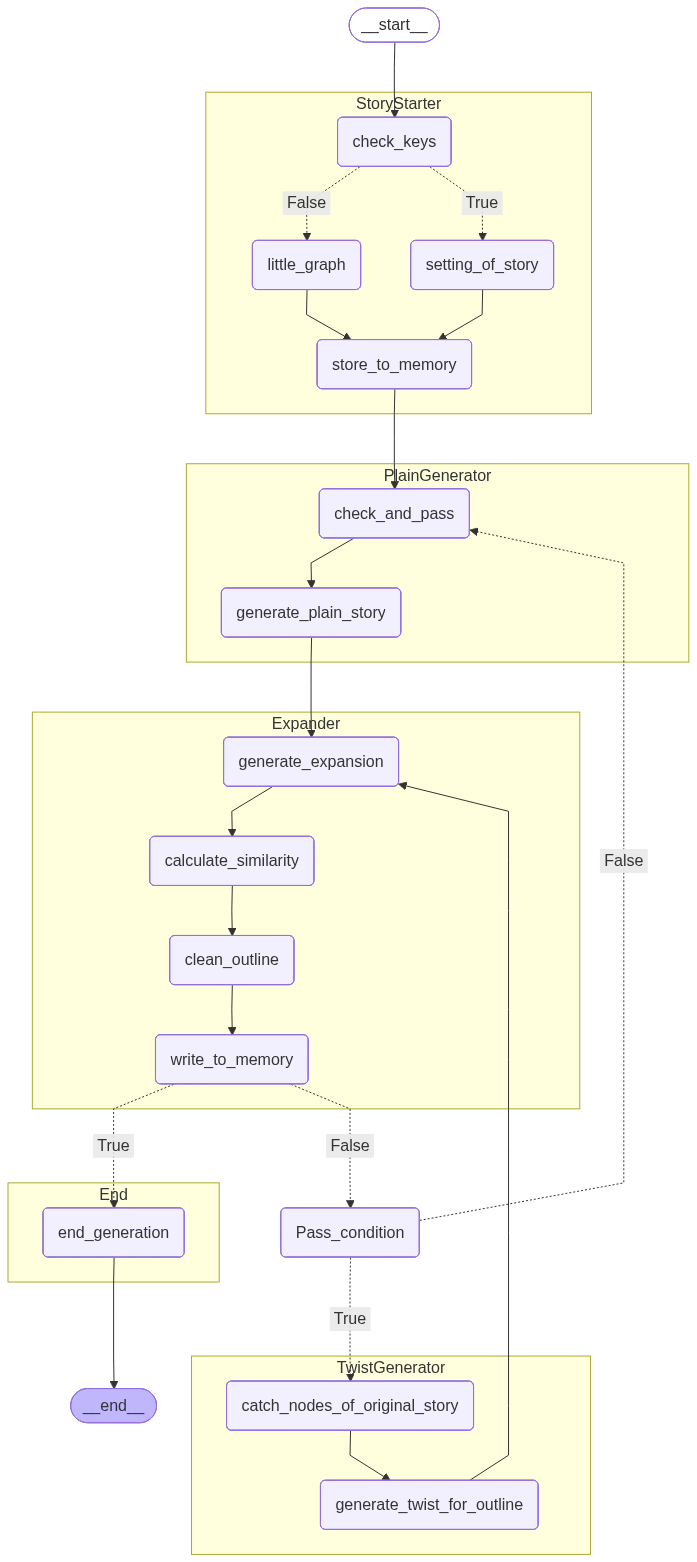

In [5]:
from IPython.display import Image, display
display(Image(main_graph.get_graph(xray=1).draw_mermaid_png()))

## Set basic information of your story
- **Language**: English, Chinese, Japanese, Korean, etc.
- **Topic**: for example, love-fiction in high school, adventure in the forest, etc. change to any topic you like.
- **MainCharacter**: for example, Allen and Mika, John and Mary, etc.
- **MainGoal**: for example, Allen and Mika get in love, John and Mary meet each other, etc.

In [6]:
initial_state = {
            "Language": "English",
            "Topic": "love-fiction in high-school and families",
            "MainCharacter": 'Ellen and Mika, two high school friends who grow up with each other',
            "MainGoal": "Mika wants to find the meaning of love and get in love with Ellen forever"
}

## Run this line
Then you can run this line to generate the story.
May take a while, but you will see how this story is generated, the process will be printed in the console below.
Using different LLMs may lead to different running time and different results. In general, the original setting of models won't lead to fails.

In [7]:
result = main_graph.invoke(initial_state,config={"recursion_limit": 100})

Setting up StoryStarterBeginning...
Generating memory...
Writing settings to your story setting path...
Writing long-term memories to your story memory path...
Setting up PlainWritingAssistant...
Reader is reading...
Editing story with reviewing...
Reader is reading...
Editing story with reviewing...
Saving story at your storage path...
0.77616835
Generating memory...
Pulling memory...
Writing long-term memories to your story memory path...
One generate round is finished. Now start to generate next round.
Setting up PlainWritingAssistant...
Reader is reading...
Editing story with reviewing...
Saving story at your storage path...
0.8042705
Generating memory...
Pulling memory...
Writing long-term memories to your story memory path...
Finally! The story's generation is finished.
Saved your story to file: result.json


If your process failed, please try again or change the params, especially the LLMs. If your process finished, you can see the result length below, and your answer will be saved in `result.json`.

In [8]:
print(f"Total Length of Story: {result['TotalStoryLength']}")

Total Length of Story: 15746


In [9]:
print(f"The shape of output be like:")
for k,v in result.items():
    print(f"{k}: Type:{type(v)}, \nvalue: {v}\n")

The shape of output be like:
MainCharacter: Type:<class 'str'>, 
value: Ellen and Mika, two high school friends who grow up with each other

MainGoal: Type:<class 'str'>, 
value: Mika wants to find the meaning of love and get in love with Ellen forever

StartSign: Type:<class 'bool'>, 
value: False

RecentStory: Type:<class 'list'>, 
value: ["Mika's confession to Ellen brings them closer together, and they embark on a journey of self-discovery and love. The morning after, Mika sends Ellen a text message asking to talk after school. Their first official day as a couple is marked by shy glances and nervous hand-holding during lunch at school. That afternoon, by the old cherry blossom tree behind the school gymnasium, Mika opens up to Ellen about his father's absence over the past six months—Mr. Tanaka took a job in another city, sending money but rarely calling, causing his mother to grow quieter and his younger sister Yumi to become more withdrawn. Mika expresses his fear of not knowing